# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [ ]:
# ! pip install pandas
# ! pip install numpy
# ! pip install matplotlib
# ! pip install seaborn
# import seaborn as sns

In [2]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

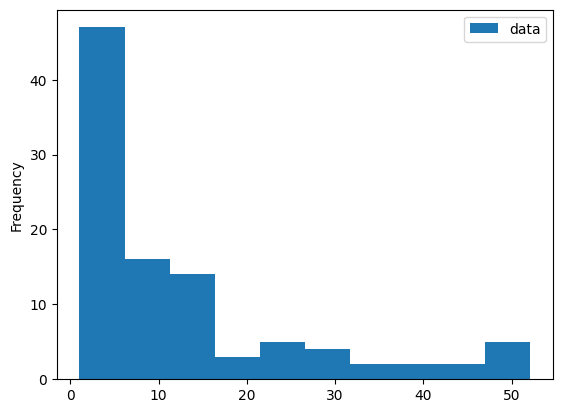

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

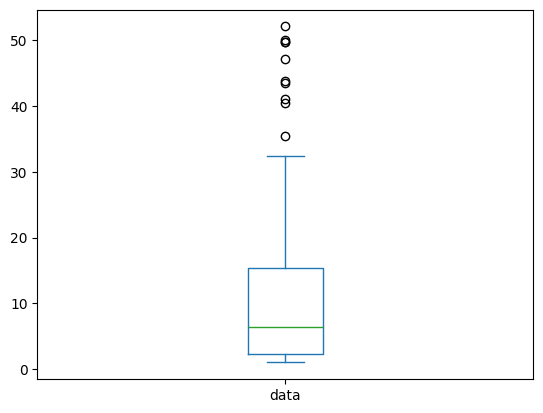

In [4]:
df.plot.box()

Problem:
Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

Histogram

Pros: Easy to get a glipse of the distribution of the data, in a relatively universal plot type.
Shows the right sided skew

Cons: Does not label the x-axis or the plot itself both of which are major drawbacks. 
No context as to whether these outliers are within the expected normal range or potential messy/incorrect data
The bins are very wide and seem to bleed into one another a bit, I would add in some white space between bins.



Box plot

Pros: Get a feel for the distribution of the data very quickly - shows a lot of good data like the median and 25-75% quartiles data.

Cons: Tend to be a bit more technical, so depending on your audience (is it just general office staff who don't know much about stats?). 
There are a decent amount of outliers - would need to look deeper at the data to understand if this is expected.
No y label or overall plot label. The x label isn't particularly helpful.

Which would I choose?

Given the two options, I think the box plot is better. While it does require a certain extent of technical knowledge, it provides a multitude of useful information. 
At a glance, you can easily see both where the majority of the data falls and the appearance of potential outliers.
While this plot could still use some improvements format wise, the histogram needs more work to make it as readable.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

ValueError: '**' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

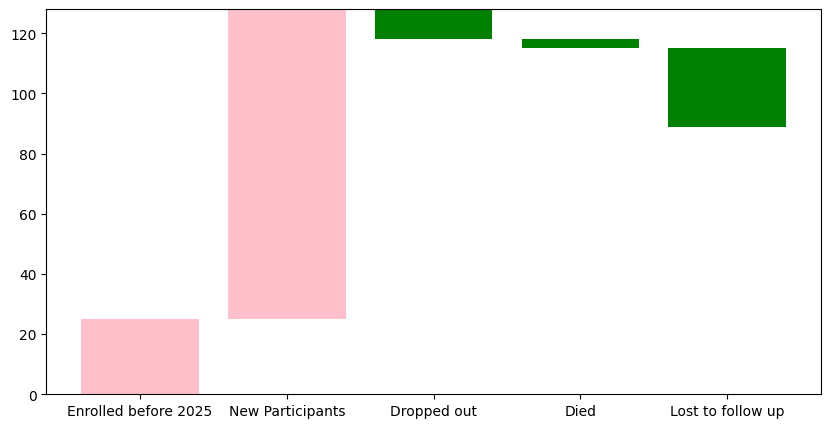

In [8]:
import matplotlib.pyplot as plt

# I want to try a waterfall chart as I don't think I've ever seen them before!
# resource: https://www.domo.com/learn/charts/waterfall-charts

# I used to work in clinical research so I want to use study enrollment

# make a df
df_enrollment = pd.DataFrame({
    "2025 Participant Types":[
        "Enrolled before 2025",
        "New Participants",
        "Dropped out",
        "Died",
        "Lost to follow up"
    ],
    "Participant Counts":[
        25,
        103,
        -10,
        -3,
        -26
    ]
})

# make sure it looks right
# df_enrollment

# determine where the bars start and how tall they each are
df_enrollment["Cumulative_Enrollment"] = df_enrollment["Participant Counts"].cumsum()
# print(df_enrollment["Cumulative_Enrollment"])
df_enrollment["Previous_Enrollment"] = df_enrollment["Cumulative_Enrollment"] - df_enrollment["Participant Counts"]
# print(df_enrollment["Previous_Enrollment"])

# now let's start making our plots!!
plt.figure(figsize=(10,5))

# let's make a loop for the bars
for n in range(len(df_enrollment)):
    if df_enrollment.loc[n, "Participant Counts"] >= 0:
        color = "pink"
    else:
        color = "green"
    
    plt.bar(
        df_enrollment.loc[n, "2025 Participant Types"],
        df_enrollment.loc[n, "Participant Counts"],
        bottom = df_enrollment.loc[n, "Previous_Enrollment"],
        color = color
    )

#  now let's work on formatting!
final_enrollment = df_enrollment["Cumulative_Enrollment"].iloc[-1]
plt.axhline(final_enrollment, linestyle="**", color ="blue")
plt.title("2025 Study Enrollment Numbers")
plt.ylabel("Participant Count")